# S&P 500 Gaussian HMM regime-count likelihood-ratio experiment

Compare $K=2,3,4$ Gaussian-emission regimes on **the same** daily S&P 500 price-index log-return sample. Fit on 1990–1999 and reserve 2000 for one-step-ahead forecast evaluation. This notebook is separate from the feature-initialization sweep: every candidate here observes the same single return series. Multiple deterministic starts reduce, but do not eliminate, EM local-optimum risk.

For adjacent models, compute the requested statistic:

$$
\mathrm{LR}_{K,K+1}=2\left[\ell_n(\hat\theta_{K+1})-\ell_n(\hat\theta_K)\right].
$$

A $K$-state univariate Gaussian HMM has $(K-1)+K(K-1)+2K=K^2+2K-1$ free parameters (initial state probabilities, transitions, and emission means/variances). The conventional reference uses $\chi^2$ with the difference in parameter counts: 7 for 2→3 and 9 for 3→4.

**Crucial qualification:** adding an HMM regime creates unidentified parameters and boundary cases under the smaller model. Therefore these conventional chi-square p-values are **not calibrated regime-count significance tests**. The notebook reports them to reproduce the paper-style calculation, but uses a finite parametric bootstrap under each fitted null model as the primary exploratory p-value. See [Kasahara and Shimotsu, *Testing the Number of Regimes in Markov Regime Switching Models*](https://arxiv.org/abs/1801.06862). Bootstrap results here are still approximate because the fitted null and finite multi-start EM are reused in simulation; increase repetitions and starts for a publication-grade analysis.

In [1]:
from pathlib import Path
from math import erfc, erf, exp, lgamma, log, sqrt
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

project_root = Path.cwd()
if not (project_root / "src/flexible_emission_hmm").exists():
    project_root = project_root.parent
if not (project_root / "src/flexible_emission_hmm").exists():
    raise FileNotFoundError("Run from the project root or notebooks directory")
sys.path.insert(0, str(project_root / "src"))

from flexible_emission_hmm.emissions import GaussianEmission
from flexible_emission_hmm.feature import daily_log_return
from flexible_emission_hmm.hmm import HMM
from flexible_emission_hmm.training import BaumWelchTrainer

DATA_PATH = project_root / "data/processed/sp500_index_price.csv"
OUTPUT_DIR = project_root / "data/artifacts/sp500_lr_test/1990_1999_train_2000_test"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
REGIMES = (2, 3, 4)
MASTER_SEED = 20261003
N_STARTS = 8
MAX_ITER = 150
TOL = 1e-3
MIN_VARIANCE = 1e-5
BOOTSTRAP_REPS = 39
BOOTSTRAP_STARTS = 2
BOOTSTRAP_MAX_ITER = 100
ALPHA = 0.05

data = pd.read_csv(DATA_PATH, parse_dates=["YYYYMMDD"]).sort_values("YYYYMMDD")
prices = data.set_index("YYYYMMDD")["DlyPrcInd"]
returns = daily_log_return(prices).dropna()
train = returns.loc["1990":"1999"]
test = returns.loc["2000"]
if len(train.index.year.unique()) != 10 or test.index.year.unique().tolist() != [2000]:
    raise ValueError("Expected exactly 1990–1999 training and 2000 evaluation")
train_mean = float(train.mean())
train_scale = float(train.std(ddof=0))
if not np.isfinite(train_scale) or train_scale <= 0:
    raise ValueError("Training returns need positive finite dispersion")
train_z = ((train - train_mean) / train_scale).to_numpy().reshape(-1, 1)
test_z = ((test - train_mean) / train_scale).to_numpy().reshape(-1, 1)
print(f"Training: {len(train)} days; evaluation: {len(test)} days")
print(f"Starts/model: {N_STARTS}; bootstrap replicates/comparison: {BOOTSTRAP_REPS}")

Training: 2528 days; evaluation: 252 days
Starts/model: 8; bootstrap replicates/comparison: 39


## Fit each regime count with multiple starts

Baum–Welch fits start and transition probabilities and Gaussian emission moments. The emission means are seeded from deterministic random observations. All models use exactly the same standardized training observations, likelihood definition, variance floor, and optimizer stopping rule. Select the best **training log likelihood** among finite attempts for each $K$; save every attempt, including failures and non-convergence. These are EM optima, not certified global MLEs.

In [2]:
def parameter_count(regimes):
    return regimes * regimes + 2 * regimes - 1


def fit_best(observations, regimes, seeds, max_iter):
    attempts = []
    best_model = None
    best_likelihood = -np.inf
    for seed in seeds:
        trainer = BaumWelchTrainer(max_iter=max_iter, tol=TOL)
        model = HMM(
            GaussianEmission(regimes, min_variance=MIN_VARIANCE, random_state=int(seed)),
            trainer=trainer,
        )
        try:
            model.fit(observations)
            likelihood = float(model.history[-1])
            if not np.isfinite(likelihood):
                raise ValueError("Non-finite training likelihood")
            attempts.append({
                "regimes": regimes, "seed": int(seed), "log_likelihood": likelihood,
                "iterations": trainer.n_iter, "converged": bool(trainer.converged),
                "error": "",
            })
            if likelihood > best_likelihood:
                best_model, best_likelihood = model, likelihood
        except (ValueError, np.linalg.LinAlgError, FloatingPointError) as error:
            attempts.append({
                "regimes": regimes, "seed": int(seed), "log_likelihood": np.nan,
                "iterations": trainer.n_iter, "converged": False,
                "error": str(error),
            })
    if best_model is None:
        raise RuntimeError(f"All {regimes}-regime fits failed")
    return best_model, pd.DataFrame(attempts)


models = {}
attempt_tables = []
model_rows = []
for regimes in REGIMES:
    seeds = [MASTER_SEED + 1000 * regimes + start for start in range(N_STARTS)]
    model, attempts = fit_best(train_z, regimes, seeds, MAX_ITER)
    models[regimes] = model
    attempt_tables.append(attempts)
    likelihood = float(model.history[-1])
    params = parameter_count(regimes)
    model_rows.append({
        "regimes": regimes, "parameters": params, "train_log_likelihood_z": likelihood,
        "aic": 2 * params - 2 * likelihood,
        "bic": params * np.log(len(train_z)) - 2 * likelihood,
        "best_seed": int(attempts.loc[attempts["log_likelihood"].idxmax(), "seed"]),
        "best_converged": bool(model.trainer.converged),
        "best_iterations": model.trainer.n_iter,
    })
model_metrics = pd.DataFrame(model_rows).set_index("regimes")
attempts = pd.concat(attempt_tables, ignore_index=True)
print(model_metrics.round(3).to_string())
print(f"Failed starts: {(attempts['error'] != '').sum()} of {len(attempts)}")

         parameters  train_log_likelihood_z       aic       bic  best_seed  best_converged  best_iterations
regimes                                                                                                    
2                 7               -3343.031  6700.062  6740.908   20263009            True               61
3                14               -3300.569  6629.139  6710.831   20264010           False              150
4                23               -3275.718  6597.436  6731.645   20265008           False              150
Failed starts: 0 of 24


## Chi-square calculation

The chi-square upper tail below is computed for integer degrees of freedom without requiring SciPy in this environment. It exactly evaluates the conventional reference distribution, **not** the true HMM regime-count null distribution. Negative raw LR values would signal that multi-start EM failed to find a nested-model improvement; the notebook stops rather than reporting a misleading p-value.

In [3]:
def chi_square_survival(statistic, degrees_of_freedom):
    if statistic < 0 or degrees_of_freedom < 1:
        raise ValueError("Statistic and degrees of freedom must be valid")
    half = degrees_of_freedom / 2
    argument = statistic / 2
    if degrees_of_freedom % 2:
        shape = 0.5
        tail = erfc(sqrt(argument))
    else:
        shape = 1.0
        tail = exp(-argument)
    while shape < half:
        term = exp(shape * log(argument) - argument - lgamma(shape + 1)) if argument > 0 else 0.0
        tail += term
        shape += 1
    return min(1.0, max(0.0, tail))


comparisons = ((2, 3), (3, 4))
lr_rows = []
for null_regimes, alternative_regimes in comparisons:
    null_ll = model_metrics.loc[null_regimes, "train_log_likelihood_z"]
    alternative_ll = model_metrics.loc[alternative_regimes, "train_log_likelihood_z"]
    statistic = float(2 * (alternative_ll - null_ll))
    if statistic < -1e-6:
        raise RuntimeError("Larger model fit below smaller model; increase starts or iterations")
    statistic = max(statistic, 0.0)
    degrees_of_freedom = int(
        model_metrics.loc[alternative_regimes, "parameters"]
        - model_metrics.loc[null_regimes, "parameters"]
    )
    lr_rows.append({
        "null": null_regimes, "alternative": alternative_regimes,
        "lr_statistic": statistic, "chi_square_df": degrees_of_freedom,
        "chi_square_p_heuristic": chi_square_survival(statistic, degrees_of_freedom),
    })
lr_table = pd.DataFrame(lr_rows).set_index(["null", "alternative"])
print(lr_table.to_string(float_format=lambda value: f"{value:.6g}"))

                  lr_statistic  chi_square_df  chi_square_p_heuristic
null alternative                                                     
2    3                 84.9235              7             1.35904e-15
3    4                 49.7024              9             1.22531e-07


## Null-model parametric bootstrap

For each adjacent comparison, simulate 39 return sequences of the original training length from the fitted smaller HMM. Refit **both** candidate sizes to each simulated sequence, recompute the LR statistic, and estimate $p=(1+\#\{\mathrm{LR}^{*}\geq\mathrm{LR}_{\mathrm{observed}}\})/(B+1)$. This preserves the fitted null's Markov dependence. The minimum attainable p-value is $1/40=0.025$; results are exploratory. The bootstrap uses two starts per replicate for runtime, fewer than the observed-data fit's eight. A negative raw LR in a replicate proves that at least one EM fit missed the theoretical nesting improvement; its frequency is reported as an optimization diagnostic. Increase `BOOTSTRAP_REPS`, `BOOTSTRAP_STARTS`, and iteration limits before drawing strong conclusions.

Bootstrap 2→3: 39 replicates complete
Bootstrap 3→4: 39 replicates complete
                  lr_statistic  chi_square_df  chi_square_p_heuristic  bootstrap_p  bootstrap_negative_raw_fraction
null alternative                                                                                                   
2    3                 84.9235              7             1.35904e-15        0.025                                0
3    4                 49.7024              9             1.22531e-07          0.3                         0.153846


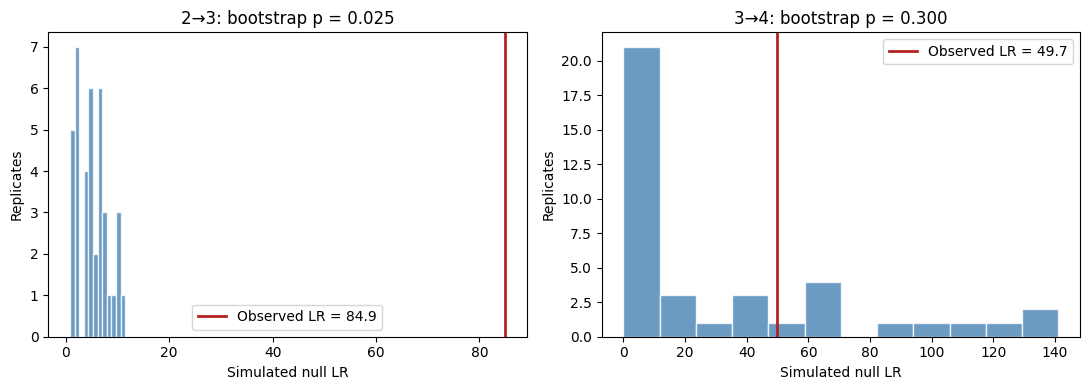

In [4]:
def simulate_hmm(model, length, rng):
    sequence = np.empty(length)
    state = int(rng.choice(model.n_states, p=model.states.start))
    means = model.emission.means[:, 0]
    standard_deviations = np.sqrt(model.emission.covariances[:, 0, 0])
    for index in range(length):
        sequence[index] = rng.normal(means[state], standard_deviations[state])
        state = int(rng.choice(model.n_states, p=model.states.transitions[state]))
    return sequence.reshape(-1, 1)


bootstrap_rows = []
for null_regimes, alternative_regimes in comparisons:
    observed_lr = lr_table.loc[(null_regimes, alternative_regimes), "lr_statistic"]
    for replicate in range(BOOTSTRAP_REPS):
        seed = MASTER_SEED + 100000 * null_regimes + replicate
        simulated = simulate_hmm(
            models[null_regimes], len(train_z), np.random.default_rng(seed)
        )
        null_seeds = [seed + 1000 + start for start in range(BOOTSTRAP_STARTS)]
        alternative_seeds = [seed + 2000 + start for start in range(BOOTSTRAP_STARTS)]
        simulated_null, _ = fit_best(
            simulated, null_regimes, null_seeds, BOOTSTRAP_MAX_ITER
        )
        simulated_alternative, _ = fit_best(
            simulated, alternative_regimes, alternative_seeds, BOOTSTRAP_MAX_ITER
        )
        simulated_lr = 2 * (
            simulated_alternative.history[-1] - simulated_null.history[-1]
        )
        bootstrap_rows.append({
            "null": null_regimes, "alternative": alternative_regimes,
            "replicate": replicate, "lr_statistic": max(0.0, float(simulated_lr)),
            "raw_lr_statistic": float(simulated_lr),
        })
    print(f"Bootstrap {null_regimes}→{alternative_regimes}: {BOOTSTRAP_REPS} replicates complete")
bootstrap = pd.DataFrame(bootstrap_rows)
for comparison in comparisons:
    subset = bootstrap.loc[
        (bootstrap["null"] == comparison[0])
        & (bootstrap["alternative"] == comparison[1]), "lr_statistic"
    ]
    observed_lr = lr_table.loc[comparison, "lr_statistic"]
    lr_table.loc[comparison, "bootstrap_p"] = (1 + int((subset >= observed_lr).sum())) / (len(subset) + 1)
    lr_table.loc[comparison, "bootstrap_negative_raw_fraction"] = float(
        (bootstrap.loc[
            (bootstrap["null"] == comparison[0])
            & (bootstrap["alternative"] == comparison[1]), "raw_lr_statistic"
        ] < 0).mean()
    )
print(lr_table.to_string(float_format=lambda value: f"{value:.6g}"))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for axis, comparison in zip(axes, comparisons):
    subset = bootstrap.loc[
        (bootstrap["null"] == comparison[0])
        & (bootstrap["alternative"] == comparison[1]), "lr_statistic"
    ]
    observed_lr = lr_table.loc[comparison, "lr_statistic"]
    axis.hist(subset, bins=12, color="steelblue", alpha=0.8, edgecolor="white")
    axis.axvline(observed_lr, color="firebrick", linewidth=2, label=f"Observed LR = {observed_lr:.1f}")
    axis.set(xlabel="Simulated null LR", ylabel="Replicates",
             title=f"{comparison[0]}→{comparison[1]}: bootstrap p = {lr_table.loc[comparison, 'bootstrap_p']:.3f}")
    axis.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "bootstrap_lr.png", dpi=160)
plt.show()

## Regime selection and held-out forecasting

Apply adjacent **bootstrap** tests sequentially at $\alpha=0.05$ for a **provisional preference**: start at two states, move to three only if 2→3 is rejected, and move to four only if 3→4 is also rejected. If an observed best fit has not converged or any bootstrap raw LR is negative, report the formal decision as **inconclusive** rather than treating that preference as a reliable selection. The chi-square heuristic and BIC are shown alongside. Evaluate all three fitted models on 2000 without refitting or using 2000 to choose the regime count. The one-step state prior at the 2000 boundary is the final 1999 filtered distribution multiplied by the transition matrix.

In [5]:
provisional_regimes = 2
for comparison in comparisons:
    if provisional_regimes == comparison[0] and lr_table.loc[comparison, "bootstrap_p"] < ALPHA:
        provisional_regimes = comparison[1]
    else:
        break
fit_diagnostics_pass = bool(model_metrics["best_converged"].all())
bootstrap_diagnostics_pass = bool((lr_table["bootstrap_negative_raw_fraction"] == 0).all())
selection_status = "provisional only; optimization diagnostics failed" if not (fit_diagnostics_pass and bootstrap_diagnostics_pass) else "exploratory bootstrap preference"
print(f"Sequential-bootstrap preference: {provisional_regimes} regimes ({selection_status})")
print(f"BIC minimum: {int(model_metrics['bic'].idxmin())} regimes")

def standard_normal_cdf(values):
    return 0.5 * (1 + np.vectorize(erf, otypes=[float])(np.asarray(values) / sqrt(2)))


forecast_rows = []
forecast_results = {}
grid = np.linspace(min(train.min(), test.min()) * 1.1, max(train.max(), test.max()) * 1.1, 600)
empirical_cdf = np.searchsorted(np.sort(test.to_numpy()), grid, side="right") / len(test)
for regimes in REGIMES:
    model = models[regimes]
    _, train_filtered, _ = model.filter(train_z)
    initial_prior = train_filtered[-1] @ model.states.transitions
    predicted, filtered, log_density_z = model.filter(test_z, initial_prior=initial_prior)
    means = model.emission.means[:, 0] * train_scale + train_mean
    standard_deviations = np.sqrt(model.emission.covariances[:, 0, 0]) * train_scale
    component_pit = standard_normal_cdf(
        (test.to_numpy()[:, None] - means[None, :]) / standard_deviations[None, :]
    )
    pit = np.sum(predicted * component_pit, axis=1)
    sorted_pit = np.sort(pit)
    pit_ks = float(np.max(np.maximum(
        np.arange(1, len(pit) + 1) / len(pit) - sorted_pit,
        sorted_pit - np.arange(len(pit)) / len(pit),
    )))
    component_cdf = standard_normal_cdf(
        (grid[:, None] - means[None, :]) / standard_deviations[None, :]
    )
    predictive_cdf = component_cdf @ predicted.mean(axis=0)
    cdf_area_pp = float(100 * np.trapezoid(np.abs(empirical_cdf - predictive_cdf), grid))
    log_density = log_density_z - np.log(train_scale)
    model_metrics.loc[regimes, "test_mean_log_density"] = float(log_density.mean())
    model_metrics.loc[regimes, "test_pit_ks"] = pit_ks
    model_metrics.loc[regimes, "test_cdf_area_pp"] = cdf_area_pp
    forecast_results[regimes] = {
        "predicted": predicted, "filtered": filtered, "pit": pit,
        "cdf": predictive_cdf, "last_train_filtered": train_filtered[-1],
        "first_test_prior": initial_prior,
    }
    forecast_rows.append(pd.DataFrame({
        "date": test.index, "regimes": regimes, "log_return": test.to_numpy(),
        "one_step_log_density": log_density, "pit": pit,
    }))
forecasts = pd.concat(forecast_rows, ignore_index=True)
print(model_metrics[["train_log_likelihood_z", "bic", "test_mean_log_density", "test_pit_ks", "test_cdf_area_pp"]].round(4).to_string())

Sequential-bootstrap preference: 3 regimes (provisional only; optimization diagnostics failed)
BIC minimum: 3 regimes
         train_log_likelihood_z        bic  test_mean_log_density  test_pit_ks  test_cdf_area_pp
regimes                                                                                         
2                    -3343.0310  6740.9084                 2.8183       0.0819            0.2072
3                    -3300.5693  6710.8312                 2.8066       0.0907            0.1945
4                    -3275.7181  6731.6455                 2.8082       0.0824            0.1712


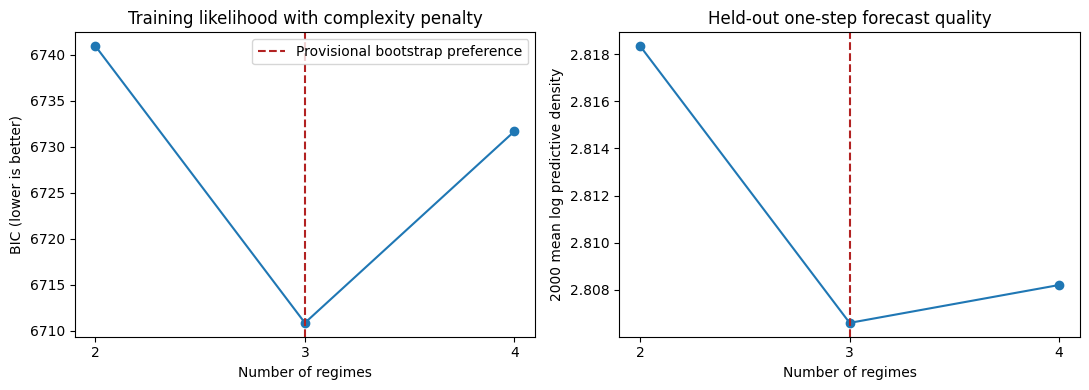

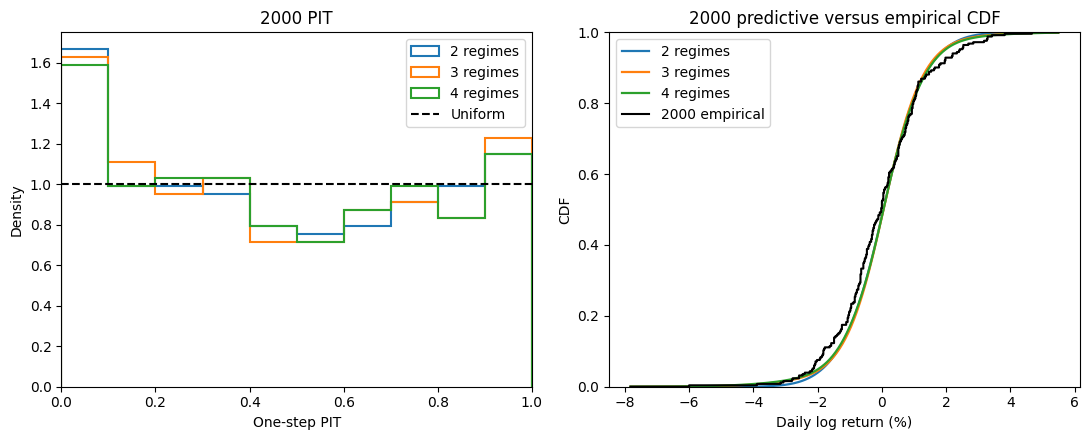

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(REGIMES, model_metrics.loc[list(REGIMES), "bic"], marker="o")
axes[0].axvline(provisional_regimes, color="firebrick", linestyle="--", label="Provisional bootstrap preference")
axes[0].set(xlabel="Number of regimes", ylabel="BIC (lower is better)",
            title="Training likelihood with complexity penalty", xticks=REGIMES)
axes[0].legend()
axes[1].plot(REGIMES, model_metrics.loc[list(REGIMES), "test_mean_log_density"], marker="o")
axes[1].axvline(provisional_regimes, color="firebrick", linestyle="--")
axes[1].set(xlabel="Number of regimes", ylabel="2000 mean log predictive density",
            title="Held-out one-step forecast quality", xticks=REGIMES)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "regime_count_metrics.png", dpi=160)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for regimes in REGIMES:
    axes[0].hist(
        forecast_results[regimes]["pit"], bins=np.linspace(0, 1, 11),
        histtype="step", density=True, linewidth=1.5, label=f"{regimes} regimes"
    )
    axes[1].plot(
        100 * grid, forecast_results[regimes]["cdf"], linewidth=1.6,
        label=f"{regimes} regimes"
    )
axes[0].axhline(1, color="black", linestyle="--", label="Uniform")
axes[0].set(xlabel="One-step PIT", ylabel="Density", title="2000 PIT", xlim=(0, 1))
axes[1].step(100 * grid, empirical_cdf, where="post", color="black", label="2000 empirical")
axes[1].set(xlabel="Daily log return (%)", ylabel="CDF", title="2000 predictive versus empirical CDF", ylim=(0, 1))
for axis in axes:
    axis.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "heldout_pit_cdf.png", dpi=160)
plt.show()

## Interpretation and reproducible artifacts

A larger model always has at least as much *theoretical* maximized training likelihood, so raw training likelihood alone cannot select $K$. Report the LR statistic, heuristic chi-square p-value, bootstrap p-value, BIC, and held-out forecast metrics together. Neither a significant LR nor a lower BIC proves that the latent states correspond to real economic phases. The 2000 return series is for predictive assessment, not model selection.

The output directory contains the attempt log, fitted parameter JSON, LR/bootstrap tables, daily forecasts, and plots. Standardized-unit training likelihoods are comparable across $K$ because the same training mean and scale are used; held-out log densities include the standardization Jacobian.

In [7]:
attempts.to_csv(OUTPUT_DIR / "fit_attempts.csv", index=False)
model_metrics.to_csv(OUTPUT_DIR / "model_metrics.csv")
lr_table.to_csv(OUTPUT_DIR / "lr_tests.csv")
bootstrap.to_csv(OUTPUT_DIR / "bootstrap_lr.csv", index=False)
forecasts.to_csv(OUTPUT_DIR / "forecasts_2000.csv", index=False)
manifest = {
    "data_path": str(DATA_PATH.relative_to(project_root)),
    "instrument": "S&P 500 price index",
    "return": "daily log return",
    "training_years": [1990, 1999],
    "evaluation_year": 2000,
    "train_days": len(train),
    "evaluation_days": len(test),
    "training_mean": train_mean,
    "training_scale": train_scale,
    "regimes": list(REGIMES),
    "n_starts": N_STARTS, "max_iter": MAX_ITER, "tol": TOL,
    "min_variance": MIN_VARIANCE, "master_seed": MASTER_SEED,
    "bootstrap_reps": BOOTSTRAP_REPS,
    "bootstrap_starts": BOOTSTRAP_STARTS,
    "bootstrap_max_iter": BOOTSTRAP_MAX_ITER,
    "selection_alpha": ALPHA,
    "provisional_regimes_by_bootstrap": provisional_regimes,
    "selection_status": selection_status,
    "models": {},
}
for regimes in REGIMES:
    model = models[regimes]
    manifest["models"][str(regimes)] = {
        "start_probabilities": model.states.start.tolist(),
        "transition_matrix": model.states.transitions.tolist(),
        "emission_means_z": model.emission.means[:, 0].tolist(),
        "emission_variances_z": model.emission.covariances[:, 0, 0].tolist(),
        "last_training_filtered": forecast_results[regimes]["last_train_filtered"].tolist(),
        "first_test_prior": forecast_results[regimes]["first_test_prior"].tolist(),
        "training_log_likelihood_z": float(model.history[-1]),
    }
(OUTPUT_DIR / "manifest.json").write_text(json.dumps(manifest, indent=2))
print(f"Saved LR experiment to {OUTPUT_DIR}")

Saved LR experiment to /Users/yushe/Desktop/UNI/FALL26/CSCD94/FlexibleEmissionHMM/data/artifacts/sp500_lr_test/1990_1999_train_2000_test
